 # Importation des librairies

In [1]:
import os
import math
import copy
import torch
import warnings
import numpy as np
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data.sampler import WeightedRandomSampler
from typing import Dict, List, Tuple
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils import weight_norm
import torch.optim as optim
import torch.optim.lr_scheduler as lr_scheduler


 # Configuration

In [2]:
# --- Constants ---
# Matches the output dimension of your pre-extracted MVIT + ResNet features
VIDEO_FEATURE_DIM = 5632
# Will be updated by setup_data_pipeline based on dataset folders
NUM_CLASSES = 2

# Training Hyperparameters (Adjust based on experimentation)
HIDDEN_DIM = 384          # Reduced LSTM hidden dimension
ATTENTION_DIM = 256         # Reduced Attention dimension
LSTM_LAYERS = 2           # Reduced LSTM layers


BATCH_SIZE = 128          # Keep or adjust based on GPU memory
NUM_EPOCHS = 100          # Reduced max epochs (early stopping will likely trigger sooner)
LEARNING_RATE = 1e-4      # Slightly reduced learning rate
WEIGHT_DECAY = 1e-3       # Significantly increased weight decay for regularization
MIXUP_ALPHA = 0.1         # Slightly increased MixUp strength
LABEL_SMOOTHING = 0.05     # Slightly increased label smoothing
EARLY_STOP_PATIENCE = 15  # Significantly reduced early stopping patience
SCHEDULER_PATIENCE = 5    # Patience for LR reduction
SCHEDULER_FACTOR = 0.5    # Factor to reduce LR by
MIN_LR = 1e-6             # Minimum learning rate


# You'll need to define the new hyperparameters, e.g.:
TRANSFORMER_HEADS = 8 # Make sure VIDEO_FEATURE_DIM (2816) is divisible by this
TRANSFORMER_LAYERS = 2
TRANSFORMER_FF_DIM = 2048 #VIDEO_FEATURE_DIM * 2 # Often 2x or 4x d_model
TRANSFORMER_DROPOUT = 0.2
CLASSIFIER_DROPOUT = 0.5 # Increased dropout



# Device Configuration
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")



Using device: cuda


 # Data Loader



 This section defines the dataset loading mechanism. It now calculates class weights for handling imbalance instead of using a sampler.

In [3]:
JSON_PATH = "train_val_videodatainfo.json"
FEATURES_DIR = "features_finetuned"
print("Using JSON_PATH=", JSON_PATH, "FEATURES_DIR=", FEATURES_DIR)

Using JSON_PATH= train_val_videodatainfo.json FEATURES_DIR= features_finetuned


In [4]:
# --- JSON-based Dataset & Data Pipeline ---
import os, json, warnings
import numpy as np
import torch
from typing import Dict, List, Tuple
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

# Paths for JSON and features directory
JSON_PATH = globals().get("JSON_PATH", "short.json")
FEATURES_DIR = globals().get("FEATURES_DIR", "features_corrected")

class VideoClassificationDataset(Dataset):
    """
    Dataset basé sur un JSON décrivant les splits et les catégories.
    Chaque entrée du JSON contient :
        {"video_id": "video7010", "category": 10, "split": "train|val|test"}
    Les features sont toutes stockées dans FEATURES_DIR sous forme .npy :
        features_corrected/video7010.npy
    """
    def __init__(self, split: str, suffix_file :str , json_path: str = JSON_PATH, features_dir: str = FEATURES_DIR):
        super().__init__()
        self.split = split
        self.json_path = json_path
        self.features_dir = features_dir
        self.suffix = suffix_file
        self.samples: List[Tuple[str, int]] = []
        self.class_counts: Dict[int, int] = {}
        self._index_from_json()

    def _index_from_json(self):
        if not os.path.isfile(self.json_path):
            raise FileNotFoundError(f"JSON file not found: {self.json_path}")
        with open(self.json_path, "r") as f:
            data = json.load(f)

        videos = data.get("videos", [])
        for v in videos:
            # On ne garde que les vidéos du split concerné
            if v.get("split") != self.split:
                continue
            vid = v.get("video_id")
            cat = int(v.get("category"))
            fpath = os.path.join(self.features_dir, f"{vid}{self.suffix}.npy")
            if os.path.exists(fpath):
                self.samples.append((fpath, cat))
                self.class_counts[cat] = self.class_counts.get(cat, 0) + 1
            else:
                warnings.warn(f"[{self.split}] Missing feature file: {fpath}")

        if not self.samples:
            raise RuntimeError(f"No samples found for split='{self.split}' using JSON={self.json_path}")

        # Update global NUM_CLASSES si défini
        unique_classes = sorted(set(lbl for _, lbl in self.samples))
        if 'NUM_CLASSES' in globals():
            globals()['NUM_CLASSES'] = max(unique_classes) + 1

        print(f"[{self.split}] Indexed {len(self.samples)} samples across {len(unique_classes)} classes.")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx: int) -> Tuple[torch.Tensor, int]:
      fpath, label = self.samples[idx]
      try:
          feats = np.load(fpath, allow_pickle=True)

          # Vérifier les NaN / Inf
          if not np.isfinite(feats).all():
              #warnings.warn(f"Invalid values (NaN/Inf) in {fpath}. Skipping sample {idx}.")
              return self.__getitem__((idx + 1) % len(self))

          x = torch.tensor(feats, dtype=torch.float32)

          if x.numel() == 0:
              #warnings.warn(f"Empty feature array at {fpath}. Skipping sample {idx}.")
              return self.__getitem__((idx + 1) % len(self))

          return x, int(label)

      except Exception as e:
          #warnings.warn(f"Error loading {fpath}: {e}. Skipping sample {idx}.")
          return self.__getitem__((idx + 1) % len(self))



def collate_fn(batch):
    """Pad variable-length sequences in batch to the max sequence length."""
    xs, ys = zip(*batch)
    lengths = [x.shape[0] if x.ndim >= 2 else 1 for x in xs]

    # Si features 1D (pas de dimension temporelle)
    if xs[0].ndim == 1:
        return torch.stack(xs, dim=0), torch.tensor(ys, dtype=torch.long)

    # Sinon, padding séquentiel
    max_len = max(lengths)
    feat_dim = xs[0].shape[-1]
    padded = torch.zeros((len(xs), max_len, feat_dim), dtype=torch.float32)
    for i, x in enumerate(xs):
        L = x.shape[0]
        padded[i, :L] = x[:L]
    return padded, torch.tensor(ys, dtype=torch.long)


def setup_data_pipeline(
    suffix=None,
    batch_size=None,
    shuffle=False,
    num_workers=0,
    use_weighted_sampler=False,
    split=None,
    **kwargs
):
    """
    Crée un DataLoader basé sur le JSON.
    Signature compatible avec ton pipeline original.
    Le split est déterminé automatiquement :
        - 'train' si shuffle=True
        - 'val' sinon
      (ou peut être explicitement passé via split='test', etc.)
    """
    bs = batch_size if batch_size is not None else globals().get("BATCH_SIZE", 32)
    if split is None:
        split = "train" if shuffle else "validate"

    dataset = VideoClassificationDataset(split=split,suffix_file=suffix, json_path=JSON_PATH, features_dir=FEATURES_DIR)

    # Calcul des poids de classe pour échantillonnage équilibré
    labels = [lbl for _, lbl in dataset.samples]
    class_counts = {lbl: labels.count(lbl) for lbl in set(labels)}
    num_classes = max(labels) + 1
    class_weights = torch.ones(num_classes, dtype=torch.float32)
    for c, cnt in class_counts.items():
        class_weights[c] = 1.0 / max(cnt, 1)

    sampler = None
    if use_weighted_sampler:
        sample_weights = [class_weights[lbl].item() for lbl in labels]
        sampler = WeightedRandomSampler(torch.tensor(sample_weights), len(sample_weights))
        shuffle = False

    loader = DataLoader(
        dataset,
        batch_size=bs,
        shuffle=shuffle and sampler is None,
        sampler=sampler,
        num_workers=num_workers,
        pin_memory=torch.cuda.is_available(),
        collate_fn=collate_fn,
    )
    return loader, num_classes


# Model MLP

In [ ]:
class SimpleMLPClassifier(nn.Module):
    def __init__(self, input_dim=2816, hidden_dim1=1024, hidden_dim2=512, num_classes=20, dropout_rate=0.5):
        """
        Args:
            input_dim (int): The size of your input feature (2816).
            hidden_dim1 (int): Size of the first hidden layer.
            hidden_dim2 (int): Size of the second hidden layer.
            num_classes (int): Number of output classes (20).
            dropout_rate (float): Dropout probability.
        """
        super(SimpleMLPClassifier, self).__init__()

        self.mlp = nn.Sequential(
            nn.Linear(input_dim, hidden_dim1),
            nn.ReLU(),
            nn.Dropout(p=dropout_rate),
            nn.Linear(hidden_dim1, hidden_dim2),
            nn.ReLU(),
            nn.Dropout(p=dropout_rate),
            nn.Linear(hidden_dim2, num_classes)
        )

    def forward(self, x):
        """
        Input x has shape (batch_size, sequence_length, input_dim)
        """
        # Apply global average pooling across the sequence_length dimension
        # Shape changes from (B, T, 2816) -> (B, 2816)
        x_pooled = torch.mean(x, dim=1)

        # Pass the pooled features through the MLP
        # Shape changes from (B, 2816) -> (B, 20)
        output = self.mlp(x_pooled)
        return output

# --- How to use ---
# model = SimpleMLPClassifier()
# dummy_input = torch.randn(32, 50, 2816)  # (batch_size=32, sequence_length=50, features=2816)
# output = model(dummy_input)
# print(output.shape)  # Should be torch.Size([32, 20])

# Model Bidirectional GRU + Attention

In [ ]:
class BiGRUAttentionClassifier(nn.Module):
    def __init__(self, input_dim=2816, gru_hidden_dim=512, num_gru_layers=1,
                 mlp_hidden_dim=512, num_classes=20, dropout_rate=0.5):
        """
        Args:
            input_dim (int): Feature dimension (2816).
            gru_hidden_dim (int): Hidden dimension of the GRU.
            num_gru_layers (int): Number of GRU layers.
            mlp_hidden_dim (int): Hidden dimension of the final classifier MLP.
            num_classes (int): Output classes (20).
            dropout_rate (float): Dropout probability.
        """
        super(BiGRUAttentionClassifier, self).__init__()

        # GRU Layer
        # batch_first=True makes input shape (B, T, F)
        self.gru = nn.GRU(
            input_size=input_dim,
            hidden_size=gru_hidden_dim,
            num_layers=num_gru_layers,
            batch_first=True,
            bidirectional=True  # This is the "Bi" in Bi-GRU
        )

        # The output of Bi-GRU has 2 * gru_hidden_dim features
        gru_output_dim = gru_hidden_dim * 2

        # Simple Attention Layer
        # We learn a linear layer to compute attention "energy" scores
        self.attention_layer = nn.Linear(gru_output_dim, 1)

        # Final Classifier MLP
        self.classifier = nn.Sequential(
            nn.Linear(gru_output_dim, mlp_hidden_dim),
            nn.ReLU(),
            nn.Dropout(p=dropout_rate),
            nn.Linear(mlp_hidden_dim, num_classes)
        )

    def forward(self, x):
        """
        Input x has shape (batch_size, sequence_length, input_dim)
        """
        # Pass features through Bi-GRU
        # gru_outputs shape: (B, T, 2 * gru_hidden_dim)
        # hidden_state shape: (2 * num_layers, B, gru_hidden_dim)
        gru_outputs, _ = self.gru(x)

        # --- Attention Mechanism ---
        # 1. Compute energy scores
        #    Shape: (B, T, 2 * gru_hidden_dim) -> (B, T, 1)
        #    We use tanh as a non-linearity
        energy = torch.tanh(self.attention_layer(gru_outputs))

        # 2. Compute attention weights using softmax
        #    Squeeze shape to (B, T)
        #    Softmax along dim=1 (the time dimension)
        #    Unsqueeze back to (B, T, 1)
        attention_weights = F.softmax(energy.squeeze(2), dim=1).unsqueeze(2)

        # 3. Compute weighted average (context vector)
        #    Element-wise multiply outputs by weights and sum along time dim
        #    Shape: (B, T, 2 * gru_hidden_dim) * (B, T, 1) -> (B, T, 2 * gru_hidden_dim)
        #    Summing along dim=1 -> (B, 2 * gru_hidden_dim)
        context_vector = torch.sum(gru_outputs * attention_weights, dim=1)

        # --- Classification ---
        # Pass the context vector through the final MLP
        # Shape: (B, 2 * gru_hidden_dim) -> (B, 20)
        output = self.classifier(context_vector)
        return output

# --- How to use ---
# model = BiGRUAttentionClassifier()
# dummy_input = torch.randn(32, 50, 2816)  # (batch_size=32, sequence_length=50, features=2816)
# output = model(dummy_input)
# print(output.shape)  # Should be torch.Size([32, 20])

# Model NetVLAD

In [ ]:
class NetVLAD(nn.Module):
    """
    NetVLAD layer implementation.
    Based on the paper: "NetVLAD: CNN architecture for weakly supervised place recognition"
    """
    def __init__(self, feature_size=2816, num_clusters=64, alpha=100.0, normalize_input=True):
        """
        Args:
            feature_size (int): Dimension of input features (2816).
            num_clusters (int): Number of clusters to learn (k).
            alpha (float): Parameter for soft-assignment scaling.
            normalize_input (bool): If True, L2-normalize input features.
        """
        super(NetVLAD, self).__init__()
        self.feature_size = feature_size
        self.num_clusters = num_clusters
        self.alpha = alpha
        self.normalize_input = normalize_input

        # Learnable cluster centers (centroids)
        # Shape: (num_clusters, feature_size)
        self.centers = nn.Parameter(torch.randn(num_clusters, feature_size))

        # This 1x1 conv computes the dot product of features with cluster centers
        # It's an efficient way to get assignment weights
        self.conv_assign = nn.Conv1d(feature_size, num_clusters, kernel_size=1, bias=True)

    def forward(self, x):
        """
        Input x has shape (batch_size, sequence_length, feature_size)
        """
        if self.normalize_input:
            x = F.normalize(x, p=2, dim=2)  # L2 normalize features

        # Transpose for 1D convolution: (B, T, D) -> (B, D, T)
        x_t = x.permute(0, 2, 1)

        # --- Soft-Assignment ---
        # Compute assignment weights
        # Shape: (B, D, T) -> (B, K, T)
        soft_assign = self.conv_assign(x_t)

        # Scale by alpha and apply softmax
        soft_assign = F.softmax(soft_assign * self.alpha, dim=1)

        # --- VLAD Core ---
        # 1. Calculate residuals (x_i - c_k)
        #    x shape: (B, T, D) -> (B, 1, T, D)
        #    centers shape: (K, D) -> (1, K, 1, D)
        #    residuals shape: (B, K, T, D)
        x_reshaped = x.unsqueeze(1)
        centers_reshaped = self.centers.unsqueeze(0).unsqueeze(2)
        residuals = x_reshaped - centers_reshaped

        # 2. Weight residuals by soft assignment
        #    soft_assign shape: (B, K, T) -> (B, K, T, 1)
        soft_assign_reshaped = soft_assign.unsqueeze(3)

        #    vlad shape: (B, K, T, D)
        vlad = residuals * soft_assign_reshaped

        # 3. Sum over time dimension (T)
        #    Shape: (B, K, T, D) -> (B, K, D)
        vlad = torch.sum(vlad, dim=2)

        # --- Normalization ---
        # 4. Intra-normalization (L2 norm across D)
        vlad = F.normalize(vlad, p=2, dim=2)

        # 5. Flatten to a single vector per video
        #    Shape: (B, K, D) -> (B, K * D)
        vlad = vlad.view(x.size(0), -1)

        # 6. Global L2 norm
        vlad = F.normalize(vlad, p=2, dim=1)

        return vlad

class NetVLADClassifier(nn.Module):
    def __init__(self, input_dim=2816, num_clusters=64,
                 hidden_dim=1024, num_classes=20, dropout_rate=0.5):
        """
        Args:
            input_dim (int): Feature dimension (2816).
            num_clusters (int): Number of VLAD clusters.
            hidden_dim (int): Hidden dimension of the final classifier MLP.
            num_classes (int): Output classes (20).
            dropout_rate (float): Dropout probability.
        """
        super(NetVLADClassifier, self).__init__()
        self.netvlad_layer = NetVLAD(
            feature_size=input_dim,
            num_clusters=num_clusters
        )

        vlad_output_dim = input_dim * num_clusters

        # Classifier MLP to reduce the very large VLAD vector
        self.classifier = nn.Sequential(
            nn.Linear(vlad_output_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(p=dropout_rate),
            nn.Linear(hidden_dim, num_classes)
        )

    def forward(self, x):
        """
        Input x has shape (batch_size, sequence_length, input_dim)
        """
        # Get the single VLAD vector per video
        # Shape: (B, T, 2816) -> (B, K * 2816)
        vlad_vector = self.netvlad_layer(x)

        # Classify the VLAD vector
        # Shape: (B, K * 2816) -> (B, 20)
        output = self.classifier(vlad_vector)
        return output

# --- How to use ---
# model = NetVLADClassifier(num_clusters=8) # Start with a small K (e.g., 8 or 16)
# dummy_input = torch.randn(32, 50, 2816)
# output = model(dummy_input)
# print(output.shape) # Should be torch.Size([32, 20])

# Model TCN

In [ ]:
# --- Helper Class 1: Chomp1d ---
# TCNs use "causal" convolutions, which means they pad the input.
# We need to "chomp" off the padding from the end of the output.
class Chomp1d(nn.Module):
    def __init__(self, chomp_size):
        super(Chomp1d, self).__init__()
        self.chomp_size = chomp_size

    def forward(self, x):
        """
        Input shape: (B, C, T)
        """
        return x[:, :, :-self.chomp_size].contiguous()


# --- Helper Class 2: TemporalBlock (Residual TCN Block) ---
class TemporalBlock(nn.Module):
    def __init__(self, n_inputs, n_outputs, kernel_size, stride, dilation, padding, dropout=0.2):
        super(TemporalBlock, self).__init__()

        # First convolutional layer
        self.conv1 = weight_norm(nn.Conv1d(n_inputs, n_outputs, kernel_size,
                                           stride=stride, padding=padding, dilation=dilation))
        self.chomp1 = Chomp1d(padding)
        self.relu1 = nn.ReLU()
        self.dropout1 = nn.Dropout(dropout)

        # Second convolutional layer
        self.conv2 = weight_norm(nn.Conv1d(n_outputs, n_outputs, kernel_size,
                                           stride=stride, padding=padding, dilation=dilation))
        self.chomp2 = Chomp1d(padding)
        self.relu2 = nn.ReLU()
        self.dropout2 = nn.Dropout(dropout)

        # The full block
        self.net = nn.Sequential(self.conv1, self.chomp1, self.relu1, self.dropout1,
                                 self.conv2, self.chomp2, self.relu2, self.dropout2)

        # 1x1 convolution for the residual connection if channel sizes don't match
        self.downsample = nn.Conv1d(n_inputs, n_outputs, 1) if n_inputs != n_outputs else None
        self.relu = nn.ReLU()
        self.init_weights()

    def init_weights(self):
        self.conv1.weight.data.normal_(0, 0.01)
        self.conv2.weight.data.normal_(0, 0.01)
        if self.downsample is not None:
            self.downsample.weight.data.normal_(0, 0.01)

    def forward(self, x):
        """
        Input shape: (B, C, T)
        """
        out = self.net(x)
        res = x if self.downsample is None else self.downsample(x)
        return self.relu(out + res)

# --- Main TCN Classifier Model ---
class TCNClassifier(nn.Module):
    def __init__(self, input_dim=2816, num_channels=[512, 256], kernel_size=3, num_classes=20, dropout=0.3):
        """
        Args:
            input_dim (int): Feature dimension (2816).
            num_channels (list): List of hidden channel sizes for each TCN layer.
                                 e.g., [512, 256] means 2 layers.
            kernel_size (int): Convolutional kernel size.
            num_classes (int): Output classes (20).
            dropout (float): Dropout rate.
        """
        super(TCNClassifier, self).__init__()
        layers = []
        num_levels = len(num_channels)

        for i in range(num_levels):
            dilation_size = 2 ** i
            in_channels = input_dim if i == 0 else num_channels[i-1]
            out_channels = num_channels[i]

            layers += [TemporalBlock(
                in_channels, out_channels, kernel_size, stride=1, dilation=dilation_size,
                padding=(kernel_size - 1) * dilation_size, dropout=dropout
            )]

        self.tcn_network = nn.Sequential(*layers)

        # Final classifier layer
        # The TCN network outputs a sequence, so we pool it.
        self.classifier = nn.Linear(num_channels[-1], num_classes)

    def forward(self, x):
        """
        Input x has shape (batch_size, sequence_length, input_dim)
        """
        # TCN expects (B, C, T) = (B, input_dim, sequence_length)
        x_t = x.permute(0, 2, 1)

        # Pass through TCN network
        # Shape: (B, input_dim, T) -> (B, num_channels[-1], T)
        tcn_out = self.tcn_network(x_t)

        # Pool the output over time. Global average pooling is common.
        # Shape: (B, num_channels[-1], T) -> (B, num_channels[-1])
        pooled_out = tcn_out.mean(dim=2)

        # Classify
        # Shape: (B, num_channels[-1]) -> (B, 20)
        output = self.classifier(pooled_out)
        return output

# --- How to use ---
# model = TCNClassifier(num_channels=[512, 512, 256]) # 3-layer TCN
# dummy_input = torch.randn(32, 50, 2816)
# output = model(dummy_input)
# print(output.shape) # Should be torch.Size([32, 20])

# Model Transformer

In [53]:
import torch
import torch.nn as nn
import math

# --- Positional Encoding ---
class PositionalEncoding(nn.Module):
    def __init__(self, d_model: int, dropout: float = 0.1, max_len: int = 5000):
        super().__init__()
        self.dropout = nn.Dropout(p=dropout)

        position = torch.arange(max_len).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2) * (-math.log(10000.0) / d_model))
        pe = torch.zeros(max_len, 1, d_model)
        pe[:, 0, 0::2] = torch.sin(position * div_term)
        pe[:, 0, 1::2] = torch.cos(position * div_term)
        self.register_buffer('pe', pe)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x: (batch, seq_len, d_model)
        x = x.permute(1, 0, 2)  # (seq_len, batch, d_model)
        x = x + self.pe[:x.size(0)]
        x = self.dropout(x)
        return x.permute(1, 0, 2)  # (batch, seq_len, d_model)


# --- Transformer Classification Model (adapted for 4×1408 segments) ---
class Transformer_Classification_Model(nn.Module):
    def __init__(self, video_feature_dim: int, num_classes: int,
                 seq_len: int = 4,
                 nhead: int = 8,
                 num_encoder_layers: int = 2,
                 dim_feedforward: int = 2048,
                 transformer_dropout: float = 0.2,
                 classifier_dropout: float = 0.5):
        super().__init__()

        # Segment length: 5632 / 4 = 1408
        self.seq_len = seq_len
        self.segment_dim = video_feature_dim // seq_len  # 1408
        self.d_model = self.segment_dim

        if self.d_model % nhead != 0:
            raise ValueError(f"d_model ({self.d_model}) must be divisible by nhead ({nhead})")

        # --- Learnable CLS Token ---
        self.cls_token = nn.Parameter(torch.zeros(1, 1, self.d_model))
        nn.init.normal_(self.cls_token, std=0.02)

        # --- Positional Encoding ---
        self.pos_encoder = PositionalEncoding(self.d_model, transformer_dropout, max_len=seq_len + 1)

        # --- Transformer Encoder ---
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=self.d_model,
            nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=transformer_dropout,
            batch_first=True
        )
        self.transformer_encoder = nn.TransformerEncoder(
            encoder_layer,
            num_layers=num_encoder_layers
        )

        # --- Classifier Head ---
        classifier_intermediate_dim = 256
        self.classifier = nn.Sequential(
            nn.LayerNorm(self.d_model),
            nn.Dropout(classifier_dropout),
            nn.Linear(self.d_model, classifier_intermediate_dim),
            nn.ReLU(),
            nn.Dropout(classifier_dropout),
            nn.Linear(classifier_intermediate_dim, num_classes)
        )

    def forward(self, features: torch.Tensor) -> torch.Tensor:
        # features: (batch_size, 5632)
        batch_size = features.size(0)

        # 1️⃣ Reshape en séquence de 4 segments
        x = features.view(batch_size, self.seq_len, self.segment_dim)  # (B, 4, 1408)

        # 2️⃣ Ajouter le token [CLS]
        cls_tokens = self.cls_token.expand(batch_size, -1, -1)  # (B, 1, 1408)
        x = torch.cat((cls_tokens, x), dim=1)  # (B, 5, 1408)

        # 3️⃣ Positional encoding
        x = self.pos_encoder(x)

        # 4️⃣ Transformer
        x = self.transformer_encoder(x)  # (B, 5, 1408)

        # 5️⃣ Utiliser le token [CLS]
        cls_output = x[:, 0]  # (B, 1408)

        # 6️⃣ Classification
        logits = self.classifier(cls_output)
        return logits


 # Model SA-LSTM



 Sequence-to-Classification Model using Bi-directional LSTM and Self-Attention, with reduced complexity.

In [11]:
class SelfAttention(nn.Module):
    """
    Self-Attention Mechanism for sequence data (LSTM outputs).
    """
    def __init__(self, hidden_dim, attention_dim, attn_dropout_rate=0.3):
        super(SelfAttention, self).__init__()
        # Bi-LSTM output is hidden_dim * 2 if num_layers=1
        self.lstm_output_dim = hidden_dim * 2

        self.W_a = nn.Linear(self.lstm_output_dim, attention_dim, bias=False)
        self.V_a = nn.Linear(attention_dim, 1, bias=False)
        self.dropout = nn.Dropout(p=attn_dropout_rate)

    def forward(self, H):
        """
        H: (batch_size, sequence_length, lstm_output_dim) -> LSTM output sequence
        """
        # Apply projection and activation
        U = torch.tanh(self.W_a(H))  # (batch_size, sequence_length, attention_dim)

        # Compute attention scores
        scores = self.V_a(U).squeeze(-1) # (batch_size, sequence_length)

        # Compute attention weights using softmax
        weights = F.softmax(scores, dim=1) # (batch_size, sequence_length)

        # Compute context vector (weighted sum of LSTM outputs)
        # weights.unsqueeze(-1): (batch_size, sequence_length, 1)
        # H:                   (batch_size, sequence_length, lstm_output_dim)
        # Result:              (batch_size, lstm_output_dim)
        context = torch.sum(weights.unsqueeze(-1) * H, dim=1)

        # Apply dropout to the context vector
        context = self.dropout(context)

        return context, weights # Return weights for potential analysis

class SA_LSTM_Classification_Model(nn.Module):
    """
    Sequence-to-Classification Model using Bi-directional LSTM and Self-Attention.
    Reduced complexity version.
    """
    def __init__(self, video_feature_dim: int, hidden_dim: int, attention_dim: int, num_classes: int):
        super(SA_LSTM_Classification_Model, self).__init__()

        self.lstm = nn.LSTM(
            input_size=video_feature_dim,
            hidden_size=hidden_dim,
            num_layers=LSTM_LAYERS, # Reduced layers
            batch_first=True,
            dropout = 0.5 if LSTM_LAYERS > 1 else 0.0, # Dropout only between LSTM layers
            bidirectional=True
        )

        lstm_output_dim = hidden_dim * 2 # Since bidirectional=True

        # Layer Normalization after LSTM - often helps stabilize training
        self.norm_lstm_out = nn.LayerNorm(lstm_output_dim)

        # Self-Attention mechanism
        self.attention = SelfAttention(hidden_dim, attention_dim) # Uses updated dimensions

        # Layer Normalization after concatenating attention context and avg pooling
        self.norm_combined = nn.LayerNorm(lstm_output_dim * 2)

        # Classifier head
        classifier_intermediate_dim = 256 # Intermediate dimension in classifier
        self.classifier = nn.Sequential(
            nn.Dropout(0.5), # Increased initial dropout
            nn.Linear(lstm_output_dim * 2, classifier_intermediate_dim), # Combined features -> Intermediate
            nn.ReLU(),
            nn.Dropout(0.5), # Dropout before final layer
            nn.Linear(classifier_intermediate_dim, num_classes) # Intermediate -> Output Classes
        )

    def forward(self, features: torch.Tensor):
        # features shape: (batch_size, sequence_length, video_feature_dim)

        # LSTM layer
        # H_out shape: (batch_size, sequence_length, hidden_dim * num_directions)
        H_out, _ = self.lstm(features)

        # Apply Layer Normalization to LSTM output sequence
        H_out_norm = self.norm_lstm_out(H_out)

        # Apply Self-Attention to normalized LSTM output
        # context shape: (batch_size, hidden_dim * num_directions)
        context, _ = self.attention(H_out_norm)

        # Average Pooling over the sequence dimension
        # avg_pool shape: (batch_size, hidden_dim * num_directions)
        avg_pool = torch.mean(H_out_norm, dim=1)

        # Concatenate Attention context and Average Pooling results
        # combined shape: (batch_size, hidden_dim * num_directions * 2)
        combined = torch.cat([context, avg_pool], dim=1)

        # Apply Layer Normalization to the combined features
        combined_norm = self.norm_combined(combined)

        # Classifier to get logits
        logits = self.classifier(combined_norm) # Use normalized combined features

        return logits


 # Training & Evaluation Functions

In [30]:
def feature_mixup(x, y, alpha=0.2):
    """Applies MixUp augmentation to feature tensors."""
    if alpha <= 0:
        return x, y, y, 1.0

    # Ensure alpha > 0 for beta distribution
    alpha = max(alpha, 1e-6)

    lam = np.random.beta(alpha, alpha)
    batch_size = x.size(0)
    index = torch.randperm(batch_size, device=x.device) # Ensure index is on the same device

    # Check if batch size is 1 to avoid error with indexing
    if batch_size == 1:
        mixed_x = x # No mixing possible
        y_a, y_b = y, y
        lam = 1.0 # Set lambda to 1
    else:
        mixed_x = lam * x + (1 - lam) * x[index, :]
        y_a, y_b = y, y[index]

    return mixed_x, y_a, y_b, lam


def train_one_epoch(model, dataloader, optimizer, criterion, device, mixup_alpha=0.2, grad_clip_value=5.0):
    """Trains the model for one epoch with MixUp and Gradient Clipping."""
    model.train()
    total_loss, total_correct, total_samples = 0.0, 0, 0

    for features, labels in dataloader:
        # Skip empty batches that might result from collate_fn filtering errors
        if features.numel() == 0:
            continue

        features, labels = features.to(device), labels.to(device)

        # --- MixUp augmentation ---
        mixed_x, y_a, y_b, lam = feature_mixup(features, labels, alpha=mixup_alpha)

        optimizer.zero_grad()
        logits = model(mixed_x)

        # --- Loss calculation for MixUp ---
        loss = lam * criterion(logits, y_a) + (1 - lam) * criterion(logits, y_b)

        loss.backward()

        # --- Gradient Clipping ---
        if grad_clip_value > 0:
            torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip_value)

        optimizer.step()

        # --- Statistics Update (use original labels for accuracy calculation) ---
        batch_size = labels.size(0)
        total_loss += loss.item() * batch_size # Accumulate loss weighted by batch size
        _, preds = torch.max(logits.data, 1)

        # Accuracy calculation needs care with Mixup.
        # A common approach is to check prediction against the dominant label (y_a if lam > 0.5 else y_b),
        # or simply against the original labels (y) as an approximation. Let's use original labels.
        total_correct += (preds == labels).sum().item()
        total_samples += batch_size

    if total_samples == 0: return 0.0, 0.0 # Avoid division by zero
    return total_loss / total_samples, 100 * total_correct / total_samples

def evaluate_model(model, dataloader, criterion, device):
    """Evaluates the model on the validation/test set."""
    model.eval()
    total_loss, total_correct, total_samples = 0.0, 0, 0

    with torch.no_grad():
        for features, labels in dataloader:
             # Skip empty batches
            if features.numel() == 0:
                continue

            features, labels = features.to(device), labels.to(device)
            outputs = model(features)

            # Check if outputs tensor is empty (shouldn't happen if features weren't empty)
            if outputs.numel() == 0:
                 continue

            loss = criterion(outputs, labels)

            batch_size = labels.size(0)
            total_loss += loss.item() * batch_size
            _, preds = torch.max(outputs, 1)
            total_correct += (preds == labels).sum().item()
            total_samples += batch_size

    if total_samples == 0: return 0.0, 0.0 # Avoid division by zero
    return total_loss / total_samples, 100 * total_correct / total_samples


# Execution Pipeline w/MLP

In [ ]:
def run_pipeline_mlp(train_data_root, val_data_root, save_path="best_sa_lstm_model.pt"):
    """
    Runs training with weighted loss, adjusted regularization, scheduler,
    early stopping and returns training logs.
    """
    print(f"\n--- Running Pipeline ---")
    print(f"Device: {DEVICE}")
    print(f"Hyperparameters:")
    print(f"  LSTM Hidden Dim: {HIDDEN_DIM}, Layers: {LSTM_LAYERS}")
    print(f"  Attention Dim: {ATTENTION_DIM}")
    print(f"  Batch Size: {BATCH_SIZE}")
    print(f"  Epochs: {NUM_EPOCHS}")
    print(f"  LR: {LEARNING_RATE}, Weight Decay: {WEIGHT_DECAY}")
    print(f"  Mixup Alpha: {MIXUP_ALPHA}, Label Smoothing: {LABEL_SMOOTHING}")
    print(f"  Early Stopping Patience: {EARLY_STOP_PATIENCE}")
    print("-" * 30)

    # --- Data Loaders & Class Weights ---
    try:
        train_loader, num_classes_train = setup_data_pipeline(
            train_data_root, BATCH_SIZE, shuffle=True, num_workers=os.cpu_count() // 2, use_weighted_sampler=True
        )
        val_loader, _ = setup_data_pipeline(
            val_data_root, BATCH_SIZE, shuffle=False, num_workers=os.cpu_count() // 2
        )
    except FileNotFoundError as e:
        print(f"Error setting up data pipeline: {e}")
        return [], [], [], [], []
    except Exception as e:
        print(f"An unexpected error occurred during data setup: {e}")
        return [], [], [], [], []


    # Use the number of classes determined from the training set
    global NUM_CLASSES
    NUM_CLASSES = num_classes_train



    model = SimpleMLPClassifier().to(DEVICE)

    # --- Loss / Optimizer / Scheduler ---
    criterion = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTHING)
    criterion_val = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTHING) # No weights for validation loss reporting

    optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

    # Scheduler monitors validation accuracy
    scheduler = lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='max', factor=SCHEDULER_FACTOR, patience=SCHEDULER_PATIENCE, min_lr=MIN_LR
    )

    # --- Logging containers ---
    train_accs, train_losses = [], []
    val_accs, val_losses = [], []
    learning_rates = []

    best_val_acc = 0.0
    best_state = None
    no_improve_epochs = 0

    # --- Training Loop ---
    for epoch in range(NUM_EPOCHS):
        try:
            train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, DEVICE, MIXUP_ALPHA)
            val_loss, val_acc = evaluate_model(model, val_loader, criterion_val, DEVICE) # Use unweighted criterion for consistent val loss metric
        except Exception as e:
            print(f"\nError during epoch {epoch+1}: {e}")
            print("Skipping epoch.")
            # Append placeholder values or handle as appropriate
            train_accs.append(float('nan'))
            train_losses.append(float('nan'))
            val_accs.append(float('nan'))
            val_losses.append(float('nan'))
            learning_rates.append(optimizer.param_groups[0]['lr'])
            continue # Move to the next epoch

        current_lr = optimizer.param_groups[0]['lr']

        # --- Logging ---
        train_accs.append(train_acc)
        train_losses.append(train_loss)
        val_accs.append(val_acc)
        val_losses.append(val_loss)
        learning_rates.append(current_lr)

        # --- Scheduler Step ---
        scheduler.step(val_acc) # Step based on validation accuracy

        print(f"Epoch {epoch+1:02d}/{NUM_EPOCHS} | "
              f"Train Acc: {train_acc:.2f}% (Loss: {train_loss:.4f}) | "
              f"Val Acc: {val_acc:.2f}% (Loss: {val_loss:.4f}) | LR: {current_lr:.6f}")

        # --- Early stopping & Checkpoint ---
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model, save_path)
            print(f"    --> New best val acc: {val_acc:.2f}%. Saved checkpoint to {save_path}")
            no_improve_epochs = 0
        else:
            no_improve_epochs += 1
            if no_improve_epochs >= EARLY_STOP_PATIENCE:
                print(f"--- Early stopping after {epoch+1} epochs (no improvement for {EARLY_STOP_PATIENCE}). ---")
                break

    # Load the best model state if it exists
    if best_state is not None:
        print(f"Loading best model weights from epoch {epoch + 1 - no_improve_epochs}.")
        model.load_state_dict(best_state)
    elif os.path.exists(save_path):
         print(f"Loading model weights from existing file: {save_path}")
         model.load_state_dict(torch.load(save_path, map_location=DEVICE))


    print(f"\n--- Training Complete. Best Val Acc: {best_val_acc:.2f}% ---")

    return train_accs, train_losses, val_accs, val_losses, learning_rates


# Execution Pipeline w/Bidirectional GRU + Attention

In [ ]:
def run_pipeline_gru(train_data_root, val_data_root, save_path="best_sa_lstm_model.pt"):
    """
    Runs training with weighted loss, adjusted regularization, scheduler,
    early stopping and returns training logs.
    """
    print(f"\n--- Running Pipeline ---")
    print(f"Device: {DEVICE}")
    print(f"Hyperparameters:")
    print(f"  LSTM Hidden Dim: {HIDDEN_DIM}, Layers: {LSTM_LAYERS}")
    print(f"  Attention Dim: {ATTENTION_DIM}")
    print(f"  Batch Size: {BATCH_SIZE}")
    print(f"  Epochs: {NUM_EPOCHS}")
    print(f"  LR: {LEARNING_RATE}, Weight Decay: {WEIGHT_DECAY}")
    print(f"  Mixup Alpha: {MIXUP_ALPHA}, Label Smoothing: {LABEL_SMOOTHING}")
    print(f"  Early Stopping Patience: {EARLY_STOP_PATIENCE}")
    print("-" * 30)

    # --- Data Loaders & Class Weights ---
    try:
        train_loader, num_classes_train = setup_data_pipeline(
            train_data_root, BATCH_SIZE, shuffle=True, num_workers=os.cpu_count() // 2, use_weighted_sampler=True
        )
        val_loader, _ = setup_data_pipeline(
            val_data_root, BATCH_SIZE, shuffle=False, num_workers=os.cpu_count() // 2
        )
    except FileNotFoundError as e:
        print(f"Error setting up data pipeline: {e}")
        return [], [], [], [], []
    except Exception as e:
        print(f"An unexpected error occurred during data setup: {e}")
        return [], [], [], [], []


    # Use the number of classes determined from the training set
    global NUM_CLASSES
    NUM_CLASSES = num_classes_train



    model = BiGRUAttentionClassifier().to(DEVICE)

    # --- Loss / Optimizer / Scheduler ---
    criterion = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTHING)
    criterion_val = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTHING) # No weights for validation loss reporting

    optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

    # Scheduler monitors validation accuracy
    scheduler = lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='max', factor=SCHEDULER_FACTOR, patience=SCHEDULER_PATIENCE, min_lr=MIN_LR
    )

    # --- Logging containers ---
    train_accs, train_losses = [], []
    val_accs, val_losses = [], []
    learning_rates = []

    best_val_acc = 0.0
    best_state = None
    no_improve_epochs = 0

    # --- Training Loop ---
    for epoch in range(NUM_EPOCHS):
        try:
            train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, DEVICE, MIXUP_ALPHA)
            val_loss, val_acc = evaluate_model(model, val_loader, criterion_val, DEVICE) # Use unweighted criterion for consistent val loss metric
        except Exception as e:
            print(f"\nError during epoch {epoch+1}: {e}")
            print("Skipping epoch.")
            # Append placeholder values or handle as appropriate
            train_accs.append(float('nan'))
            train_losses.append(float('nan'))
            val_accs.append(float('nan'))
            val_losses.append(float('nan'))
            learning_rates.append(optimizer.param_groups[0]['lr'])
            continue # Move to the next epoch

        current_lr = optimizer.param_groups[0]['lr']

        # --- Logging ---
        train_accs.append(train_acc)
        train_losses.append(train_loss)
        val_accs.append(val_acc)
        val_losses.append(val_loss)
        learning_rates.append(current_lr)

        # --- Scheduler Step ---
        scheduler.step(val_acc) # Step based on validation accuracy

        print(f"Epoch {epoch+1:02d}/{NUM_EPOCHS} | "
              f"Train Acc: {train_acc:.2f}% (Loss: {train_loss:.4f}) | "
              f"Val Acc: {val_acc:.2f}% (Loss: {val_loss:.4f}) | LR: {current_lr:.6f}")

        # --- Early stopping & Checkpoint ---
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model, save_path)
            print(f"    --> New best val acc: {val_acc:.2f}%. Saved checkpoint to {save_path}")
            no_improve_epochs = 0
        else:
            no_improve_epochs += 1
            if no_improve_epochs >= EARLY_STOP_PATIENCE:
                print(f"--- Early stopping after {epoch+1} epochs (no improvement for {EARLY_STOP_PATIENCE}). ---")
                break

    # Load the best model state if it exists
    if best_state is not None:
        print(f"Loading best model weights from epoch {epoch + 1 - no_improve_epochs}.")
        model.load_state_dict(best_state)
    elif os.path.exists(save_path):
         print(f"Loading model weights from existing file: {save_path}")
         model.load_state_dict(torch.load(save_path, map_location=DEVICE))


    print(f"\n--- Training Complete. Best Val Acc: {best_val_acc:.2f}% ---")

    return train_accs, train_losses, val_accs, val_losses, learning_rates


# Execution Pipeline w/NetVLAD

In [ ]:
def run_pipeline_vlad(train_data_root, val_data_root, save_path="best_sa_lstm_model.pt"):
    """
    Runs training with weighted loss, adjusted regularization, scheduler,
    early stopping and returns training logs.
    """
    print(f"\n--- Running Pipeline ---")
    print(f"Device: {DEVICE}")
    print(f"Hyperparameters:")
    print(f"  LSTM Hidden Dim: {HIDDEN_DIM}, Layers: {LSTM_LAYERS}")
    print(f"  Attention Dim: {ATTENTION_DIM}")
    print(f"  Batch Size: {BATCH_SIZE}")
    print(f"  Epochs: {NUM_EPOCHS}")
    print(f"  LR: {LEARNING_RATE}, Weight Decay: {WEIGHT_DECAY}")
    print(f"  Mixup Alpha: {MIXUP_ALPHA}, Label Smoothing: {LABEL_SMOOTHING}")
    print(f"  Early Stopping Patience: {EARLY_STOP_PATIENCE}")
    print("-" * 30)

    # --- Data Loaders & Class Weights ---
    try:
        train_loader, num_classes_train = setup_data_pipeline(
            train_data_root, BATCH_SIZE, shuffle=True, num_workers=os.cpu_count() // 2, use_weighted_sampler=True
        )
        val_loader, _ = setup_data_pipeline(
            val_data_root, BATCH_SIZE, shuffle=False, num_workers=os.cpu_count() // 2
        )
    except FileNotFoundError as e:
        print(f"Error setting up data pipeline: {e}")
        return [], [], [], [], []
    except Exception as e:
        print(f"An unexpected error occurred during data setup: {e}")
        return [], [], [], [], []


    # Use the number of classes determined from the training set
    global NUM_CLASSES
    NUM_CLASSES = num_classes_train



    model = NetVLADClassifier(num_clusters=8).to(DEVICE)

    # --- Loss / Optimizer / Scheduler ---
    criterion = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTHING)
    criterion_val = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTHING) # No weights for validation loss reporting

    optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

    # Scheduler monitors validation accuracy
    scheduler = lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='max', factor=SCHEDULER_FACTOR, patience=SCHEDULER_PATIENCE, min_lr=MIN_LR
    )

    # --- Logging containers ---
    train_accs, train_losses = [], []
    val_accs, val_losses = [], []
    learning_rates = []

    best_val_acc = 0.0
    best_state = None
    no_improve_epochs = 0

    # --- Training Loop ---
    for epoch in range(NUM_EPOCHS):
        try:
            train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, DEVICE, MIXUP_ALPHA)
            val_loss, val_acc = evaluate_model(model, val_loader, criterion_val, DEVICE) # Use unweighted criterion for consistent val loss metric
        except Exception as e:
            print(f"\nError during epoch {epoch+1}: {e}")
            print("Skipping epoch.")
            # Append placeholder values or handle as appropriate
            train_accs.append(float('nan'))
            train_losses.append(float('nan'))
            val_accs.append(float('nan'))
            val_losses.append(float('nan'))
            learning_rates.append(optimizer.param_groups[0]['lr'])
            continue # Move to the next epoch

        current_lr = optimizer.param_groups[0]['lr']

        # --- Logging ---
        train_accs.append(train_acc)
        train_losses.append(train_loss)
        val_accs.append(val_acc)
        val_losses.append(val_loss)
        learning_rates.append(current_lr)

        # --- Scheduler Step ---
        scheduler.step(val_acc) # Step based on validation accuracy

        print(f"Epoch {epoch+1:02d}/{NUM_EPOCHS} | "
              f"Train Acc: {train_acc:.2f}% (Loss: {train_loss:.4f}) | "
              f"Val Acc: {val_acc:.2f}% (Loss: {val_loss:.4f}) | LR: {current_lr:.6f}")

        # --- Early stopping & Checkpoint ---
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model, save_path)
            print(f"    --> New best val acc: {val_acc:.2f}%. Saved checkpoint to {save_path}")
            no_improve_epochs = 0
        else:
            no_improve_epochs += 1
            if no_improve_epochs >= EARLY_STOP_PATIENCE:
                print(f"--- Early stopping after {epoch+1} epochs (no improvement for {EARLY_STOP_PATIENCE}). ---")
                break

    # Load the best model state if it exists
    if best_state is not None:
        print(f"Loading best model weights from epoch {epoch + 1 - no_improve_epochs}.")
        model.load_state_dict(best_state)
    elif os.path.exists(save_path):
         print(f"Loading model weights from existing file: {save_path}")
         model.load_state_dict(torch.load(save_path, map_location=DEVICE))


    print(f"\n--- Training Complete. Best Val Acc: {best_val_acc:.2f}% ---")

    return train_accs, train_losses, val_accs, val_losses, learning_rates


# Execution Pipeline w/TCN

In [ ]:
def run_pipeline_tcn(train_data_root, val_data_root, save_path="best_sa_lstm_model.pt"):
    """
    Runs training with weighted loss, adjusted regularization, scheduler,
    early stopping and returns training logs.
    """
    print(f"\n--- Running Pipeline ---")
    print(f"Device: {DEVICE}")
    print(f"Hyperparameters:")
    print(f"  LSTM Hidden Dim: {HIDDEN_DIM}, Layers: {LSTM_LAYERS}")
    print(f"  Attention Dim: {ATTENTION_DIM}")
    print(f"  Batch Size: {BATCH_SIZE}")
    print(f"  Epochs: {NUM_EPOCHS}")
    print(f"  LR: {LEARNING_RATE}, Weight Decay: {WEIGHT_DECAY}")
    print(f"  Mixup Alpha: {MIXUP_ALPHA}, Label Smoothing: {LABEL_SMOOTHING}")
    print(f"  Early Stopping Patience: {EARLY_STOP_PATIENCE}")
    print("-" * 30)

    # --- Data Loaders & Class Weights ---
    try:
        train_loader, num_classes_train = setup_data_pipeline(
            train_data_root, BATCH_SIZE, shuffle=True, num_workers=os.cpu_count() // 2, use_weighted_sampler=True
        )
        val_loader, _ = setup_data_pipeline(
            val_data_root, BATCH_SIZE, shuffle=False, num_workers=os.cpu_count() // 2
        )
    except FileNotFoundError as e:
        print(f"Error setting up data pipeline: {e}")
        return [], [], [], [], []
    except Exception as e:
        print(f"An unexpected error occurred during data setup: {e}")
        return [], [], [], [], []


    # Use the number of classes determined from the training set
    global NUM_CLASSES
    NUM_CLASSES = num_classes_train



    model = TCNClassifier(num_channels=[512, 512, 256]).to(DEVICE)

    # --- Loss / Optimizer / Scheduler ---
    criterion = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTHING)
    criterion_val = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTHING) # No weights for validation loss reporting

    optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

    # Scheduler monitors validation accuracy
    scheduler = lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='max', factor=SCHEDULER_FACTOR, patience=SCHEDULER_PATIENCE, min_lr=MIN_LR
    )

    # --- Logging containers ---
    train_accs, train_losses = [], []
    val_accs, val_losses = [], []
    learning_rates = []

    best_val_acc = 0.0
    best_state = None
    no_improve_epochs = 0

    # --- Training Loop ---
    for epoch in range(NUM_EPOCHS):
        try:
            train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, DEVICE, MIXUP_ALPHA)
            val_loss, val_acc = evaluate_model(model, val_loader, criterion_val, DEVICE) # Use unweighted criterion for consistent val loss metric
        except Exception as e:
            print(f"\nError during epoch {epoch+1}: {e}")
            print("Skipping epoch.")
            # Append placeholder values or handle as appropriate
            train_accs.append(float('nan'))
            train_losses.append(float('nan'))
            val_accs.append(float('nan'))
            val_losses.append(float('nan'))
            learning_rates.append(optimizer.param_groups[0]['lr'])
            continue # Move to the next epoch

        current_lr = optimizer.param_groups[0]['lr']

        # --- Logging ---
        train_accs.append(train_acc)
        train_losses.append(train_loss)
        val_accs.append(val_acc)
        val_losses.append(val_loss)
        learning_rates.append(current_lr)

        # --- Scheduler Step ---
        scheduler.step(val_acc) # Step based on validation accuracy

        print(f"Epoch {epoch+1:02d}/{NUM_EPOCHS} | "
              f"Train Acc: {train_acc:.2f}% (Loss: {train_loss:.4f}) | "
              f"Val Acc: {val_acc:.2f}% (Loss: {val_loss:.4f}) | LR: {current_lr:.6f}")

        # --- Early stopping & Checkpoint ---
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model, save_path)
            print(f"    --> New best val acc: {val_acc:.2f}%. Saved checkpoint to {save_path}")
            no_improve_epochs = 0
        else:
            no_improve_epochs += 1
            if no_improve_epochs >= EARLY_STOP_PATIENCE:
                print(f"--- Early stopping after {epoch+1} epochs (no improvement for {EARLY_STOP_PATIENCE}). ---")
                break

    # Load the best model state if it exists
    if best_state is not None:
        print(f"Loading best model weights from epoch {epoch + 1 - no_improve_epochs}.")
        model.load_state_dict(best_state)
    elif os.path.exists(save_path):
         print(f"Loading model weights from existing file: {save_path}")
         model.load_state_dict(torch.load(save_path, map_location=DEVICE))


    print(f"\n--- Training Complete. Best Val Acc: {best_val_acc:.2f}% ---")

    return train_accs, train_losses, val_accs, val_losses, learning_rates


# Execution Pipeline w/Transformer

In [55]:
def run_pipeline_transformer(train_data_root, val_data_root, save_path="best_sa_lstm_model.pt"):
    """
    Runs training with weighted loss, adjusted regularization, scheduler,
    early stopping and returns training logs.
    """
    print(f"\n--- Running Pipeline ---")
    print(f"Device: {DEVICE}")
    print(f"Hyperparameters:")
    print(f"  LSTM Hidden Dim: {HIDDEN_DIM}, Layers: {LSTM_LAYERS}")
    print(f"  Attention Dim: {ATTENTION_DIM}")
    print(f"  Batch Size: {BATCH_SIZE}")
    print(f"  Epochs: {NUM_EPOCHS}")
    print(f"  LR: {LEARNING_RATE}, Weight Decay: {WEIGHT_DECAY}")
    print(f"  Mixup Alpha: {MIXUP_ALPHA}, Label Smoothing: {LABEL_SMOOTHING}")
    print(f"  Early Stopping Patience: {EARLY_STOP_PATIENCE}")
    print("-" * 30)

    # --- Data Loaders & Class Weights ---
    try:
        train_loader, num_classes_train = setup_data_pipeline(
            train_data_root, BATCH_SIZE, shuffle=True, num_workers=os.cpu_count() // 2, use_weighted_sampler=True
        )
        val_loader, _ = setup_data_pipeline(
            val_data_root, BATCH_SIZE, shuffle=False, num_workers=os.cpu_count() // 2
        )
    except FileNotFoundError as e:
        print(f"Error setting up data pipeline: {e}")
        return [], [], [], [], []
    except Exception as e:
        print(f"An unexpected error occurred during data setup: {e}")
        return [], [], [], [], []


    # Use the number of classes determined from the training set
    global NUM_CLASSES
    NUM_CLASSES = num_classes_train



    model = Transformer_Classification_Model(
        video_feature_dim=VIDEO_FEATURE_DIM,
        num_classes=NUM_CLASSES,
        nhead=TRANSFORMER_HEADS,
        num_encoder_layers=TRANSFORMER_LAYERS,
        dim_feedforward=TRANSFORMER_FF_DIM,
        transformer_dropout=TRANSFORMER_DROPOUT,
        classifier_dropout=CLASSIFIER_DROPOUT
    ).to(DEVICE)

    # --- Loss / Optimizer / Scheduler ---
    criterion = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTHING)
    criterion_val = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTHING) # No weights for validation loss reporting

    optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

    # Scheduler monitors validation accuracy
    scheduler = lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='max', factor=SCHEDULER_FACTOR, patience=SCHEDULER_PATIENCE, min_lr=MIN_LR
    )

    # --- Logging containers ---
    train_accs, train_losses = [], []
    val_accs, val_losses = [], []
    learning_rates = []

    best_val_acc = 0.0
    best_state = None
    no_improve_epochs = 0

    # --- Training Loop ---
    for epoch in range(NUM_EPOCHS):
        try:
            train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, DEVICE, MIXUP_ALPHA)
            val_loss, val_acc = evaluate_model(model, val_loader, criterion_val, DEVICE) # Use unweighted criterion for consistent val loss metric
        except Exception as e:
            print(f"\nError during epoch {epoch+1}: {e}")
            print("Skipping epoch.")
            # Append placeholder values or handle as appropriate
            train_accs.append(float('nan'))
            train_losses.append(float('nan'))
            val_accs.append(float('nan'))
            val_losses.append(float('nan'))
            learning_rates.append(optimizer.param_groups[0]['lr'])
            continue # Move to the next epoch

        current_lr = optimizer.param_groups[0]['lr']

        # --- Logging ---
        train_accs.append(train_acc)
        train_losses.append(train_loss)
        val_accs.append(val_acc)
        val_losses.append(val_loss)
        learning_rates.append(current_lr)

        # --- Scheduler Step ---
        scheduler.step(val_acc) # Step based on validation accuracy

        print(f"Epoch {epoch+1:02d}/{NUM_EPOCHS} | "
              f"Train Acc: {train_acc:.2f}% (Loss: {train_loss:.4f}) | "
              f"Val Acc: {val_acc:.2f}% (Loss: {val_loss:.4f}) | LR: {current_lr:.6f}")

        # --- Early stopping & Checkpoint ---
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model, save_path)
            print(f"    --> New best val acc: {val_acc:.2f}%. Saved checkpoint to {save_path}")
            no_improve_epochs = 0
        else:
            no_improve_epochs += 1
            if no_improve_epochs >= EARLY_STOP_PATIENCE:
                print(f"--- Early stopping after {epoch+1} epochs (no improvement for {EARLY_STOP_PATIENCE}). ---")
                break



    print(f"\n--- Training Complete. Best Val Acc: {best_val_acc:.2f}% ---")

    return train_accs, train_losses, val_accs, val_losses, learning_rates


 # Execution Pipeline



 Runs the full training and validation loop with adjusted hyperparameters and logic.

In [ ]:
def run_pipeline(suffix, val_data_root, save_path="best_sa_lstm_model.pt"):
    """
    Runs training with weighted loss, adjusted regularization, scheduler,
    early stopping and returns training logs.
    """
    print(f"\n--- Running Pipeline ---")
    print(f"Device: {DEVICE}")
    print(f"Hyperparameters:")
    print(f"  LSTM Hidden Dim: {HIDDEN_DIM}, Layers: {LSTM_LAYERS}")
    print(f"  Attention Dim: {ATTENTION_DIM}")
    print(f"  Batch Size: {BATCH_SIZE}")
    print(f"  Epochs: {NUM_EPOCHS}")
    print(f"  LR: {LEARNING_RATE}, Weight Decay: {WEIGHT_DECAY}")
    print(f"  Mixup Alpha: {MIXUP_ALPHA}, Label Smoothing: {LABEL_SMOOTHING}")
    print(f"  Early Stopping Patience: {EARLY_STOP_PATIENCE}")
    print("-" * 30)

    # --- Data Loaders & Class Weights ---
    try:
        train_loader, num_classes_train = setup_data_pipeline(
            suffix, BATCH_SIZE, shuffle=True, num_workers=os.cpu_count() // 2, use_weighted_sampler=True
        )
        val_loader, _ = setup_data_pipeline(
            suffix, BATCH_SIZE, shuffle=False, num_workers=os.cpu_count() // 2
        )
    except FileNotFoundError as e:
        print(f"Error setting up data pipeline: {e}")
        return [], [], [], [], []
    except Exception as e:
        print(f"An unexpected error occurred during data setup: {e}")
        return [], [], [], [], []


    # Use the number of classes determined from the training set
    global NUM_CLASSES
    NUM_CLASSES = num_classes_train

    # --- Model ---
    model = SA_LSTM_Classification_Model(
        video_feature_dim=VIDEO_FEATURE_DIM,
        hidden_dim=HIDDEN_DIM,
        attention_dim=ATTENTION_DIM,
        num_classes=NUM_CLASSES
    ).to(DEVICE)

    # --- Loss / Optimizer / Scheduler ---
    criterion = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTHING)
    criterion_val = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTHING) # No weights for validation loss reporting

    optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

    # Scheduler monitors validation accuracy
    scheduler = lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='max', factor=SCHEDULER_FACTOR, patience=SCHEDULER_PATIENCE, min_lr=MIN_LR
    )

    # --- Logging containers ---
    train_accs, train_losses = [], []
    val_accs, val_losses = [], []
    learning_rates = []

    best_val_acc = 0.0
    best_state = None
    no_improve_epochs = 0

    # --- Training Loop ---
    for epoch in range(NUM_EPOCHS):
        try:
            train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, DEVICE, MIXUP_ALPHA)
            val_loss, val_acc = evaluate_model(model, val_loader, criterion_val, DEVICE) # Use unweighted criterion for consistent val loss metric
        except Exception as e:
            print(f"\nError during epoch {epoch+1}: {e}")
            print("Skipping epoch.")
            # Append placeholder values or handle as appropriate
            train_accs.append(float('nan'))
            train_losses.append(float('nan'))
            val_accs.append(float('nan'))
            val_losses.append(float('nan'))
            learning_rates.append(optimizer.param_groups[0]['lr'])
            continue # Move to the next epoch

        current_lr = optimizer.param_groups[0]['lr']

        # --- Logging ---
        train_accs.append(train_acc)
        train_losses.append(train_loss)
        val_accs.append(val_acc)
        val_losses.append(val_loss)
        learning_rates.append(current_lr)

        # --- Scheduler Step ---
        scheduler.step(val_acc) # Step based on validation accuracy

        print(f"Epoch {epoch+1:02d}/{NUM_EPOCHS} | "
              f"Train Acc: {train_acc:.2f}% (Loss: {train_loss:.4f}) | "
              f"Val Acc: {val_acc:.2f}% (Loss: {val_loss:.4f}) | LR: {current_lr:.6f}")

        # --- Early stopping & Checkpoint ---
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model, save_path)
            print(f"    --> New best val acc: {val_acc:.2f}%. Saved checkpoint to {save_path}")
            no_improve_epochs = 0
        else:
            no_improve_epochs += 1
            if no_improve_epochs >= EARLY_STOP_PATIENCE:
                print(f"--- Early stopping after {epoch+1} epochs (no improvement for {EARLY_STOP_PATIENCE}). ---")
                break



    print(f"\n--- Training Complete. Best Val Acc: {best_val_acc:.2f}% ---")

    return train_accs, train_losses, val_accs, val_losses, learning_rates


 # Run Experiment

 **Important:** Replace `'./TrainValFeatures_v2/Train/'` and `'./TrainValFeatures_v2/Val/'` with the actual paths to your training and validation feature directories containing the `.npy` files.

In [ ]:
# --- Constants ---
# Matches the output dimension of your pre-extracted MVIT + ResNet features
VIDEO_FEATURE_DIM = 5632
# Will be updated by setup_data_pipeline based on dataset folders
NUM_CLASSES = 2

# Training Hyperparameters (Adjust based on experimentation)
HIDDEN_DIM = 384          # Reduced LSTM hidden dimension
ATTENTION_DIM = 512         # Reduced Attention dimension
LSTM_LAYERS = 2           # Reduced LSTM layers


BATCH_SIZE = 128          # Keep or adjust based on GPU memory
NUM_EPOCHS = 100          # Reduced max epochs (early stopping will likely trigger sooner)
LEARNING_RATE = 1e-4      # Slightly reduced learning rate
WEIGHT_DECAY = 1e-3       # Significantly increased weight decay for regularization
MIXUP_ALPHA = 0.1         # Slightly increased MixUp strength
LABEL_SMOOTHING = 0.05     # Slightly increased label smoothing
EARLY_STOP_PATIENCE = 15  # Significantly reduced early stopping patience
SCHEDULER_PATIENCE = 5    # Patience for LR reduction
SCHEDULER_FACTOR = 0.5    # Factor to reduce LR by
MIN_LR = 1e-6             # Minimum learning rate



# Device Configuration
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")




train_feature_dir = '_flow'
val_feature_dir = './TrainValFeatures_v2/Val/'
model_save_file = "best_lstm_flow_feature.pt" # Give it a new name


train_acc_history, train_loss_history, val_acc_history, val_loss_history, lr_history = run_pipeline(
    train_feature_dir, val_feature_dir, save_path=model_save_file
)



In [ ]:
# Define the paths to your extracted features
# !!! UPDATE THESE PATHS !!!
train_feature_dir = './TrainValFeatures_v2/Train/'
val_feature_dir = './TrainValFeatures_v2/Val/'
model_save_file = "best_transf_model_v2.pt" # Give it a new name


train_acc_history, train_loss_history, val_acc_history, val_loss_history, lr_history = run_pipeline(
    train_feature_dir, val_feature_dir, save_path=model_save_file
)



In [ ]:
# Define the paths to your extracted features
# !!! UPDATE THESE PATHS !!!
train_feature_dir = './TrainValFeatures_v2/Train/'
val_feature_dir = './TrainValFeatures_v2/Val/'
model_save_file = "best_transf_model_v2.pt" # Give it a new name


train_acc_history, train_loss_history, val_acc_history, val_loss_history, lr_history = run_pipeline(
    train_feature_dir, val_feature_dir, save_path=model_save_file
)




--- Running Pipeline ---
Device: cuda
Hyperparameters:
  LSTM Hidden Dim: 384, Layers: 2
  Attention Dim: 256
  Batch Size: 128
  Epochs: 100
  LR: 0.0001, Weight Decay: 0.001
  Mixup Alpha: 0.1, Label Smoothing: 0.05
  Early Stopping Patience: 15
------------------------------
[train] Indexed 6513 samples across 20 classes.
[validate] Indexed 497 samples across 20 classes.
Epoch 01/100 | Train Acc: 5.59% (Loss: 3.0204) | Val Acc: 5.43% (Loss: 2.9810) | LR: 0.000100
    --> New best val acc: 5.43%. Saved checkpoint to best_transf_model_v2.pt
Epoch 02/100 | Train Acc: 12.01% (Loss: 2.7656) | Val Acc: 42.86% (Loss: 2.0598) | LR: 0.000100
    --> New best val acc: 42.86%. Saved checkpoint to best_transf_model_v2.pt
Epoch 03/100 | Train Acc: 36.02% (Loss: 1.4949) | Val Acc: 48.09% (Loss: 2.2368) | LR: 0.000100
    --> New best val acc: 48.09%. Saved checkpoint to best_transf_model_v2.pt
Epoch 04/100 | Train Acc: 42.02% (Loss: 1.1580) | Val Acc: 48.89% (Loss: 2.3878) | LR: 0.000100
    -->

In [33]:
import numpy as np, os, torch

folder = "features_finetuned"
n_nan = 0
n_empty = 0
n_tot = 0
for f in os.listdir(folder):
    n_tot += 1
    if not f.endswith(".npy"):
        continue
    arr = np.load(os.path.join(folder, f), allow_pickle=True)
    if np.isnan(arr).any() or np.isinf(arr).any():
        print("⚠️ NaN/Inf found in:", f, arr.shape)
        n_nan += 1
    if arr.size == 0:
        print("⚠️ Empty feature file:", f)
        n_empty += 1

print(f"\nRésumé: {n_nan} fichiers contiennent des NaN/Inf, {n_empty} fichiers vides. {n_tot} total")



Résumé: 0 fichiers contiennent des NaN/Inf, 0 fichiers vides. 10000 total


 # Plot Metrics

In [5]:
import matplotlib.pyplot as plt

def plot_metrics(train_accs, train_losses, val_accs, val_losses, learning_rates):
    """Plots training and validation metrics along with the learning rate."""
    epochs = range(1, len(train_accs) + 1)

    # Check if there's any data to plot
    if not epochs:
        print("No data available to plot. Ensure training ran for at least one epoch.")
        return

    fig, ax1 = plt.subplots(figsize=(14, 7)) # Increased figure size

    # Plotting Accuracy on primary y-axis (left)
    color = 'tab:blue'
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Accuracy (%)', color=color)
    ax1.plot(epochs, train_accs, color=color, linestyle='-', marker='o', markersize=4, label='Train Acc')
    ax1.plot(epochs, val_accs, color=color, linestyle='--', marker='x', markersize=4, label='Val Acc')
    ax1.tick_params(axis='y', labelcolor=color)
    ax1.grid(True, linestyle=':')

    # Add horizontal line for best Validation Accuracy
    if val_accs: # Ensure val_accs is not empty
        valid_val_accs = [acc for acc in val_accs if not np.isnan(acc)] # Filter out NaNs
        if valid_val_accs:
            best_val_acc = max(valid_val_accs)
            best_epoch = valid_val_accs.index(best_val_acc) + 1
            ax1.axhline(y=best_val_acc, color='grey', linestyle='--', linewidth=1)
            ax1.text(0.02, best_val_acc + 1, f'Best Val Acc: {best_val_acc:.2f}% (Epoch {best_epoch})',
                     transform=ax1.get_yaxis_transform(), verticalalignment='bottom', fontsize=9) # Relative position

    # Instantiate a second axes that shares the same x-axis for Loss
    ax2 = ax1.twinx()
    color = 'tab:red'
    ax2.set_ylabel('Loss', color=color)
    ax2.plot(epochs, train_losses, color=color, linestyle='-', marker='o', markersize=4, label='Train Loss')
    ax2.plot(epochs, val_losses, color=color, linestyle='--', marker='x', markersize=4, label='Val Loss')
    ax2.tick_params(axis='y', labelcolor=color)

    # Instantiate a third axes for Learning Rate
    ax3 = ax1.twinx()
    # Offset the right spine of ax3
    ax3.spines['right'].set_position(('outward', 60))
    color = 'tab:green'
    ax3.set_ylabel('Learning Rate', color=color)
    ax3.plot(epochs, learning_rates, color=color, linestyle='-.', marker='s', markersize=4, label='LR')
    ax3.tick_params(axis='y', labelcolor=color)
    ax3.set_yscale('log') # Use log scale for LR often makes changes more visible

    # Combine legends
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    lines3, labels3 = ax3.get_legend_handles_labels()
    # Place legend outside the plot area
    ax1.legend(lines1 + lines2 + lines3, labels1 + labels2 + labels3, loc='upper center',
               bbox_to_anchor=(0.5, -0.1), fancybox=True, shadow=True, ncol=3)

    plt.title('Training Metrics')
    fig.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to make room for legend below axis
    plt.show()


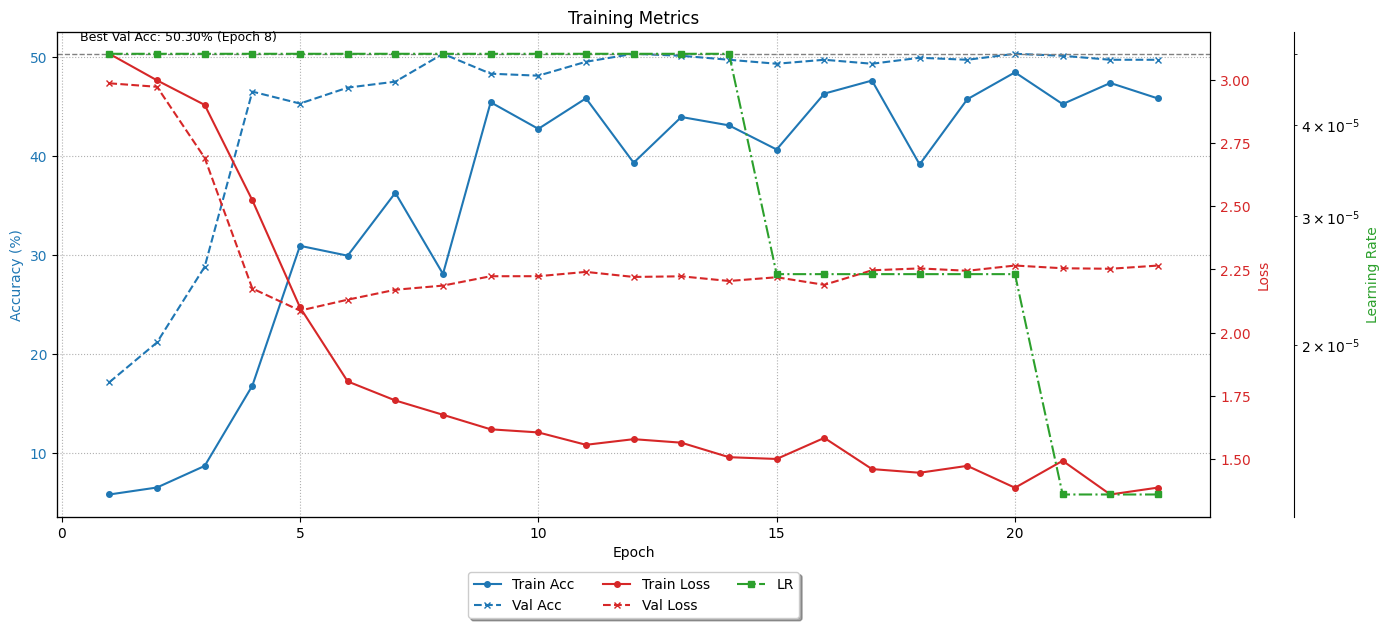

In [41]:
# Plot the results from the training run
plot_metrics(train_acc_history, train_loss_history, val_acc_history, val_loss_history, lr_history)

# TEST

In [24]:

# ==== Configuration ====
from pathlib import Path

FEATURE_DIR = Path('./features_finetuned')
JSON_PATH_TEST = Path('./test_videodatainfo.json')
CATEGORY_TXT = Path('./category.txt')
MODEL_PATH = Path('./best_sa_lstm_53,1.pt')

DEVICE = 'cuda'  # or 'cpu'
NUM_CLASSES = 20  # number of categories


In [25]:

import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import json
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')


In [26]:

def load_category_map(category_txt: Path):
    idx2name, name2idx = {}, {}
    with open(category_txt, 'r', encoding='utf-8') as f:
        for line in f:
            parts = [p.strip() for p in line.strip().split('\t') if p.strip()]
            if len(parts) != 2:
                continue
            name, idx = (parts[0], int(parts[1])) if parts[1].isdigit() else (parts[1], int(parts[0]))
            idx2name[idx] = name
            name2idx[name] = idx
    return idx2name, name2idx


def load_json_videos(json_path: Path, split='test'):
    with open(json_path, 'r', encoding='utf-8') as f:
        data = json.load(f)
    return [v for v in data.get('videos', []) if v.get('split', '').lower() == split]


In [27]:

idx2name, name2idx = load_category_map(CATEGORY_TXT)
test_videos = load_json_videos(JSON_PATH_TEST, split='test')
print(f"Loaded {len(test_videos)} test entries.")

samples = []
for v in test_videos:
    vid, cat = v['video_id'], int(v['category'])
    npy_path = FEATURE_DIR / f"{vid}.npy"
    if npy_path.exists():
        samples.append({'id': vid, 'path': npy_path, 'label': cat})
    else:
        print(f"[WARN] Missing feature for {vid}")
print(f"Using {len(samples)} features for evaluation.")


Loaded 2990 test entries.
Using 2990 features for evaluation.


In [29]:
print(model)

SA_LSTM_Classification_Model(
  (lstm): LSTM(1408, 384, num_layers=2, batch_first=True, dropout=0.5, bidirectional=True)
  (norm_lstm_out): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
  (attention): SelfAttention(
    (W_a): Linear(in_features=768, out_features=256, bias=False)
    (V_a): Linear(in_features=256, out_features=1, bias=False)
    (dropout): Dropout(p=0.3, inplace=False)
  )
  (norm_combined): LayerNorm((1536,), eps=1e-05, elementwise_affine=True)
  (classifier): Sequential(
    (0): Dropout(p=0.5, inplace=False)
    (1): Linear(in_features=1536, out_features=256, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.5, inplace=False)
    (4): Linear(in_features=256, out_features=20, bias=True)
  )
)


In [35]:

device = torch.device(DEVICE if torch.cuda.is_available() and DEVICE == 'cuda' else 'cpu')
probe = np.load(samples[0]['path'])
feature_dim = probe.shape[1] if probe.ndim == 2 else probe.shape[0]
print(f"Feature dimension: {feature_dim}")

model = torch.load(MODEL_PATH, map_location=device, weights_only=False)
model.to(device)
model.eval()
print(f"Loaded checkpoint from {MODEL_PATH}")

y_true, y_pred_top1 = [], []
top1_correct = top2_correct = top3_correct = top4_correct = top5_correct = 0

for s in tqdm(samples, desc="Evaluating"):
    feats = np.load(s['path'])  # shape: (5632,)
    x = torch.from_numpy(feats).unsqueeze(0).float().to(device)
    x = x.view(1, 4, 1408)

    with torch.no_grad():
        logits = model(x)
        probs = torch.softmax(logits, dim=1)
        topk = torch.topk(probs, k=3, dim=1)  # top-3 prédictions

        topk_indices = topk.indices.squeeze(0).tolist()
        pred_top1 = topk_indices[0]

    label = s['label']
    y_true.append(label)
    y_pred_top1.append(pred_top1)

    # Comptage top-k
    if label == topk_indices[0]:
        top1_correct += 1
    if label in topk_indices[:2]:
        top2_correct += 1
    if label in topk_indices[:3]:
        top3_correct += 1
    if label in topk_indices[:4]:
        top4_correct += 1
    if label in topk_indices[:5]:
        top5_correct += 1

# -------------------------
# MÉTRIQUES
# -------------------------
N = len(samples)
top1_acc = top1_correct / N
top2_acc = top2_correct / N
top3_acc = top3_correct / N
top4_acc = top4_correct / N
top5_acc = top5_correct / N

f1_macro = f1_score(y_true, y_pred_top1, average='macro')
f1_micro = f1_score(y_true, y_pred_top1, average='micro')

print(f"\nTop-1 Accuracy : {top1_acc:.6f}")
print(f"Top-2 Accuracy : {top2_acc:.6f}")
print(f"Top-3 Accuracy : {top3_acc:.6f}")
print(f"Top-4 Accuracy : {top4_acc:.6f}")
print(f"Top-5 Accuracy : {top5_acc:.6f}")
print(f"Macro-F1       : {f1_macro:.4f}")
print(f"Micro-F1       : {f1_micro:.4f}\n")

print(classification_report(
    y_true, y_pred_top1, digits=3,
    target_names=[idx2name.get(i, str(i)) for i in range(NUM_CLASSES)]
))


Feature dimension: 5632
Loaded checkpoint from best_sa_lstm_53,1.pt


Evaluating: 100%|██████████| 2990/2990 [00:05<00:00, 557.30it/s]


Top-1 Accuracy : 0.530769
Top-2 Accuracy : 0.673244
Top-3 Accuracy : 0.737124
Top-4 Accuracy : 0.737124
Top-5 Accuracy : 0.737124
Macro-F1       : 0.4660
Micro-F1       : 0.5308

                      precision    recall  f1-score   support

               music      0.480     0.425     0.451       226
              people      0.189     0.228     0.207        79
              gaming      0.554     0.617     0.584       141
      sports/actions      0.808     0.728     0.766       324
news/events/politics      0.440     0.584     0.502       137
           education      0.362     0.392     0.377        74
            tv shows      0.190     0.260     0.220        77
        movie/comedy      0.531     0.512     0.521       301
           animation      0.538     0.525     0.531       122
      vehicles/autos      0.756     0.775     0.765       244
               howto      0.559     0.549     0.554       173
              travel      0.437     0.507     0.469        75
  science/tec

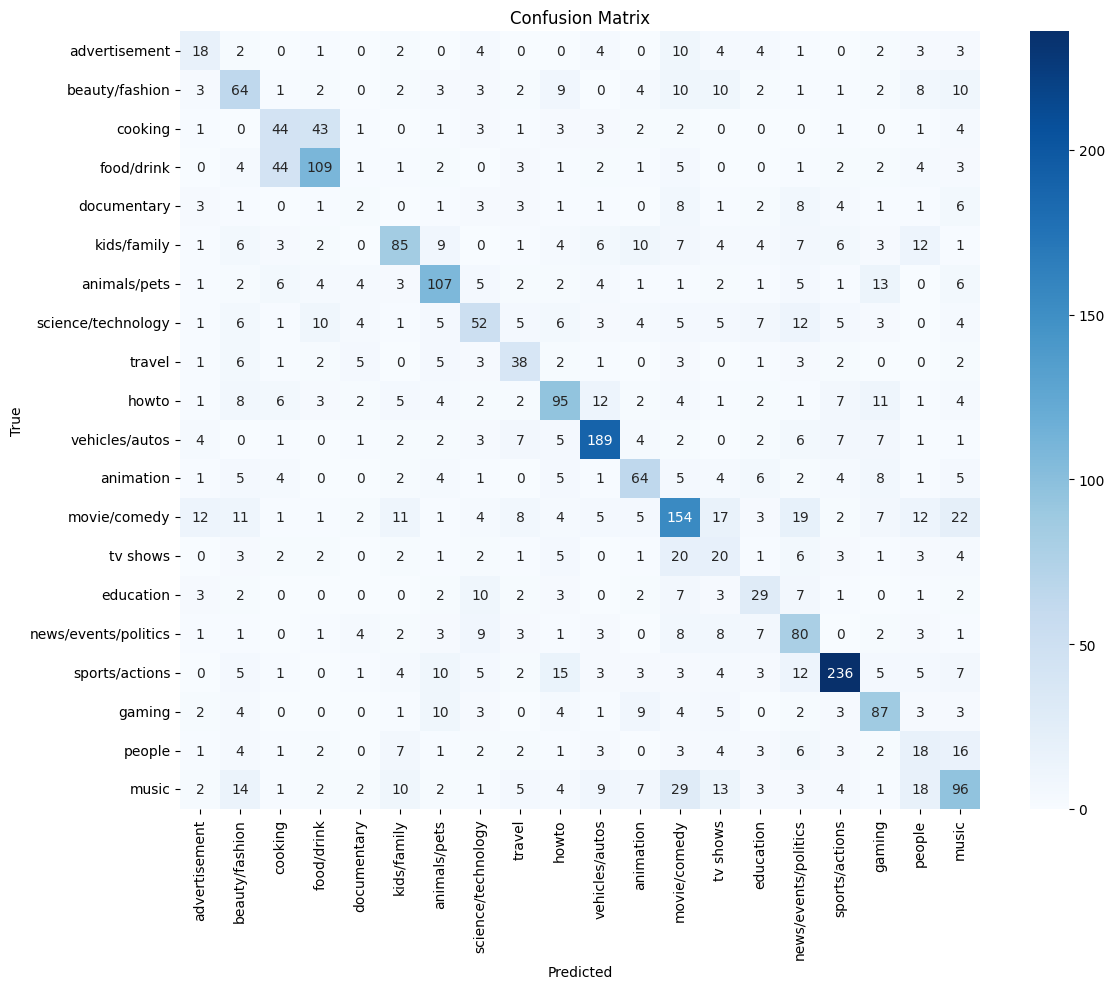

In [36]:

cm = confusion_matrix(y_true, y_pred_top1, labels=list(range(NUM_CLASSES)))
plt.figure(figsize=(12, 10))
sns.heatmap(cm, cmap='Blues',
            annot=True,
            fmt='d',
            xticklabels=[idx2name.get(i, str(i)) for i in range(NUM_CLASSES)],
            yticklabels=[idx2name.get(i, str(i)) for i in range(NUM_CLASSES)])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.tight_layout()

plt.gca().invert_yaxis()
plt.gca().invert_xaxis()
plt.show()


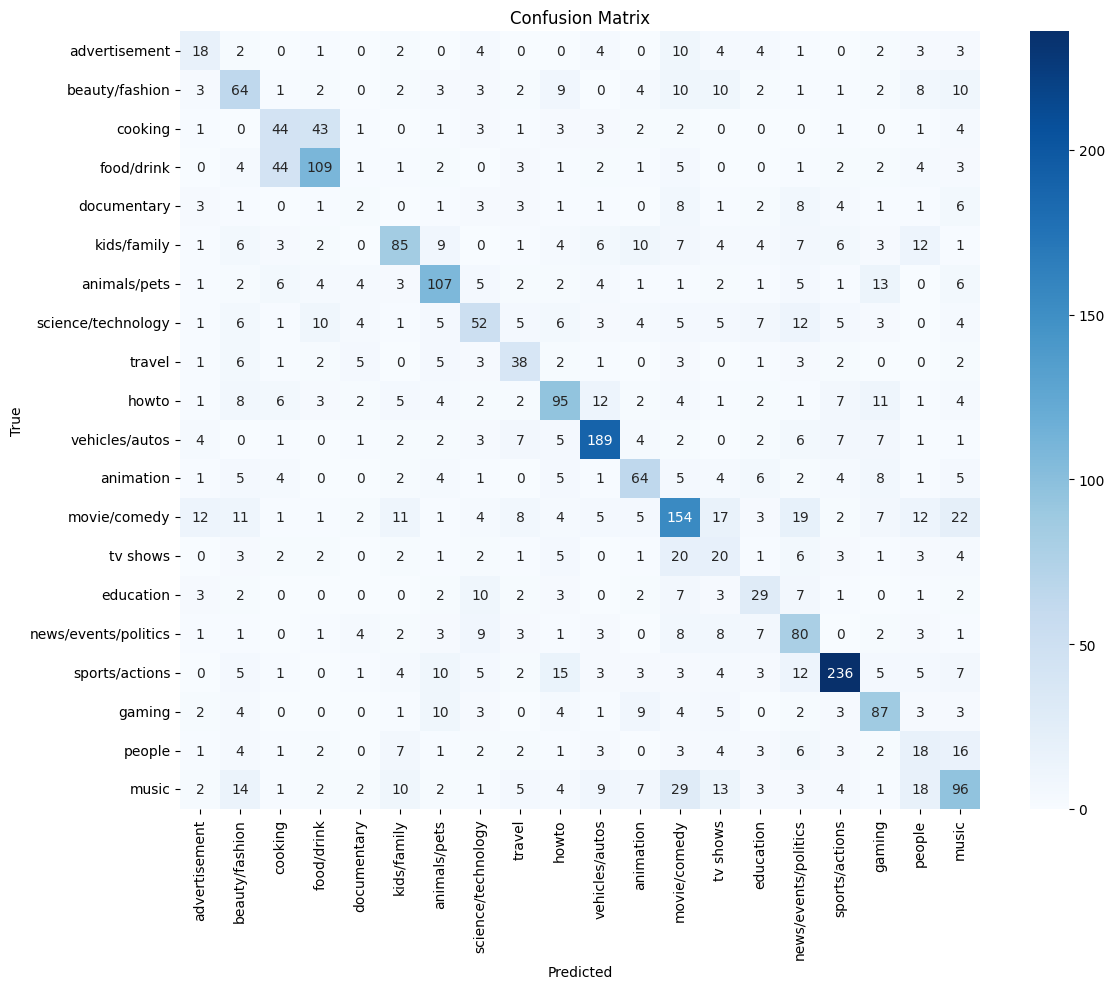

In [51]:

cm = confusion_matrix(y_true, y_pred, labels=list(range(NUM_CLASSES)))
plt.figure(figsize=(12, 10))
sns.heatmap(cm, cmap='Blues',
            annot=True,
            fmt='d',
            xticklabels=[idx2name.get(i, str(i)) for i in range(NUM_CLASSES)],
            yticklabels=[idx2name.get(i, str(i)) for i in range(NUM_CLASSES)])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.tight_layout()

plt.gca().invert_yaxis()
plt.gca().invert_xaxis()
plt.show()


# STORING RESULTS

## SA-LSTM MAX SCORE 50.3%

## MLP MAX SCORE 48.49% 100epochs

In [ ]:
# --- Constants ---
# Matches the output dimension of your pre-extracted MVIT + ResNet features
VIDEO_FEATURE_DIM = 2816
# Will be updated by setup_data_pipeline based on dataset folders
NUM_CLASSES = 2

# Training Hyperparameters (Adjust based on experimentation)
HIDDEN_DIM = 256          # Reduced LSTM hidden dimension
ATTENTION_DIM = 128         # Reduced Attention dimension
LSTM_LAYERS = 4           # Reduced LSTM layers


BATCH_SIZE = 128          # Keep or adjust based on GPU memory
NUM_EPOCHS = 100          # Reduced max epochs (early stopping will likely trigger sooner)
LEARNING_RATE = 1e-4      # Slightly reduced learning rate
WEIGHT_DECAY = 1e-3       # Significantly increased weight decay for regularization
MIXUP_ALPHA = 0.2         # Slightly increased MixUp strength
LABEL_SMOOTHING = 0.1    # Slightly increased label smoothing
EARLY_STOP_PATIENCE = 15  # Significantly reduced early stopping patience
SCHEDULER_PATIENCE = 5    # Patience for LR reduction
SCHEDULER_FACTOR = 0.5    # Factor to reduce LR by
MIN_LR = 1e-6             # Minimum learning rate

## GRU MAX SCORE 49.7% 77 epochs, train at 60%, overfits

In [ ]:
# --- Constants ---
# Matches the output dimension of your pre-extracted MVIT + ResNet features
VIDEO_FEATURE_DIM = 2816
# Will be updated by setup_data_pipeline based on dataset folders
NUM_CLASSES = 2

# Training Hyperparameters (Adjust based on experimentation)
HIDDEN_DIM = 256          # Reduced LSTM hidden dimension
ATTENTION_DIM = 128         # Reduced Attention dimension
LSTM_LAYERS = 4           # Reduced LSTM layers


BATCH_SIZE = 128          # Keep or adjust based on GPU memory
NUM_EPOCHS = 100          # Reduced max epochs (early stopping will likely trigger sooner)
LEARNING_RATE = 1e-4      # Slightly reduced learning rate
WEIGHT_DECAY = 1e-3       # Significantly increased weight decay for regularization
MIXUP_ALPHA = 0.2         # Slightly increased MixUp strength
LABEL_SMOOTHING = 0.1    # Slightly increased label smoothing
EARLY_STOP_PATIENCE = 15  # Significantly reduced early stopping patience
SCHEDULER_PATIENCE = 5    # Patience for LR reduction
SCHEDULER_FACTOR = 0.5    # Factor to reduce LR by
MIN_LR = 1e-6             # Minimum learning rate

## VLAD MAX SCORE 14.29% 23epochs, train at 10.35%

In [ ]:
# --- Constants ---
# Matches the output dimension of your pre-extracted MVIT + ResNet features
VIDEO_FEATURE_DIM = 2816
# Will be updated by setup_data_pipeline based on dataset folders
NUM_CLASSES = 2

# Training Hyperparameters (Adjust based on experimentation)
HIDDEN_DIM = 256          # Reduced LSTM hidden dimension
ATTENTION_DIM = 128         # Reduced Attention dimension
LSTM_LAYERS = 4           # Reduced LSTM layers


BATCH_SIZE = 128          # Keep or adjust based on GPU memory
NUM_EPOCHS = 100          # Reduced max epochs (early stopping will likely trigger sooner)
LEARNING_RATE = 1e-4      # Slightly reduced learning rate
WEIGHT_DECAY = 1e-3       # Significantly increased weight decay for regularization
MIXUP_ALPHA = 0.2         # Slightly increased MixUp strength
LABEL_SMOOTHING = 0.1    # Slightly increased label smoothing
EARLY_STOP_PATIENCE = 15  # Significantly reduced early stopping patience
SCHEDULER_PATIENCE = 5    # Patience for LR reduction
SCHEDULER_FACTOR = 0.5    # Factor to reduce LR by
MIN_LR = 1e-6             # Minimum learning rate

## TCN MAX SCORE 47.08%, train at 57.78%, overfits

In [ ]:
# --- Constants ---
# Matches the output dimension of your pre-extracted MVIT + ResNet features
VIDEO_FEATURE_DIM = 2816
# Will be updated by setup_data_pipeline based on dataset folders
NUM_CLASSES = 2

# Training Hyperparameters (Adjust based on experimentation)
HIDDEN_DIM = 256          # Reduced LSTM hidden dimension
ATTENTION_DIM = 128         # Reduced Attention dimension
LSTM_LAYERS = 4           # Reduced LSTM layers


BATCH_SIZE = 128          # Keep or adjust based on GPU memory
NUM_EPOCHS = 100          # Reduced max epochs (early stopping will likely trigger sooner)
LEARNING_RATE = 1e-4      # Slightly reduced learning rate
WEIGHT_DECAY = 1e-3       # Significantly increased weight decay for regularization
MIXUP_ALPHA = 0.2         # Slightly increased MixUp strength
LABEL_SMOOTHING = 0.1    # Slightly increased label smoothing
EARLY_STOP_PATIENCE = 15  # Significantly reduced early stopping patience
SCHEDULER_PATIENCE = 5    # Patience for LR reduction
SCHEDULER_FACTOR = 0.5    # Factor to reduce LR by
MIN_LR = 1e-6             # Minimum learning rate